# Task 3: GARCH volatility modelling


In [1]:
from __future__ import annotations
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np

from task3_helpers import (
    clean_dataframe,
    GARCHSpec,
    fit,
    select_all_series,
    evaluate_holdout_all_series,
    holdout_summary,
)


## Configuration

In [2]:
DB_PATH        = Path("spiff_data.db")
OUTPUT_DIR     = Path("outputs")
FORECAST_HORIZON = 200
N_PATHS        = 1000

## Load data

Log-returns are loaded from DuckDB and cleaned via the shared Task 1 routines
re-exported from `task3_helpers`. The last 200 observations are reserved as the
holdout window.


In [3]:
with duckdb.connect(DB_PATH) as conn:
    cols = conn.execute("DESCRIBE transformed_data").df()["column_name"].tolist()
    val_cols = [c for c in cols if "logreturn" in c]
    returns_df = conn.execute(
        f"SELECT day, {', '.join(val_cols)} FROM transformed_data"
    ).df()
    price_cols = conn.execute("DESCRIBE spiff").df()["column_name"].tolist()
    price_cols = [c for c in price_cols if c != "day"]
    prices_df = conn.execute(
        f"SELECT day, {', '.join(price_cols)} FROM spiff"
    ).df()

returns_df = returns_df.set_index("day")
prices_df  = prices_df.set_index("day")

df_clean = clean_dataframe(returns_df, truncate_at=5255)
train_df = df_clean.iloc[:-FORECAST_HORIZON]

print(f"Series  : {val_cols}")
print(f"Full shape : {df_clean.shape}")
print(f"Train shape: {train_df.shape}")

Series  : ['gurkor_logreturn', 'guitars_logreturn', 'slingshots_logreturn', 'stocks_logreturn', 'sugar_logreturn', 'water_logreturn', 'tranquillity_logreturn']
Full shape : (5254, 7)
Train shape: (5054, 7)


In [4]:
last_prices = {
    asset: float(prices_df[asset].dropna().iloc[-1])
    for asset in prices_df.columns
}
forecast_start_day = int(prices_df.dropna(how='all').index.max()) + 1
print(f'Forecast origin day: {forecast_start_day}')
print(f'Last prices: { {k: round(v,4) for k,v in last_prices.items()} }')


Forecast origin day: 5257
Last prices: {'gurkor': 13.7919, 'guitars': 8.0849, 'slingshots': 6.419, 'stocks': 6.513, 'sugar': 2.7606, 'water': 8.7386, 'tranquillity': 12.2314}


## Regime break detection

Financial return series often have multiple variance regimes. We detect variance
breaks with the ICSS algorithm (Inclán & Tiao 1994) and then compare three
training-window strategies on a GARCH(1,1)-normal baseline: full sample,
post-break window, and a rolling 1000-day window.


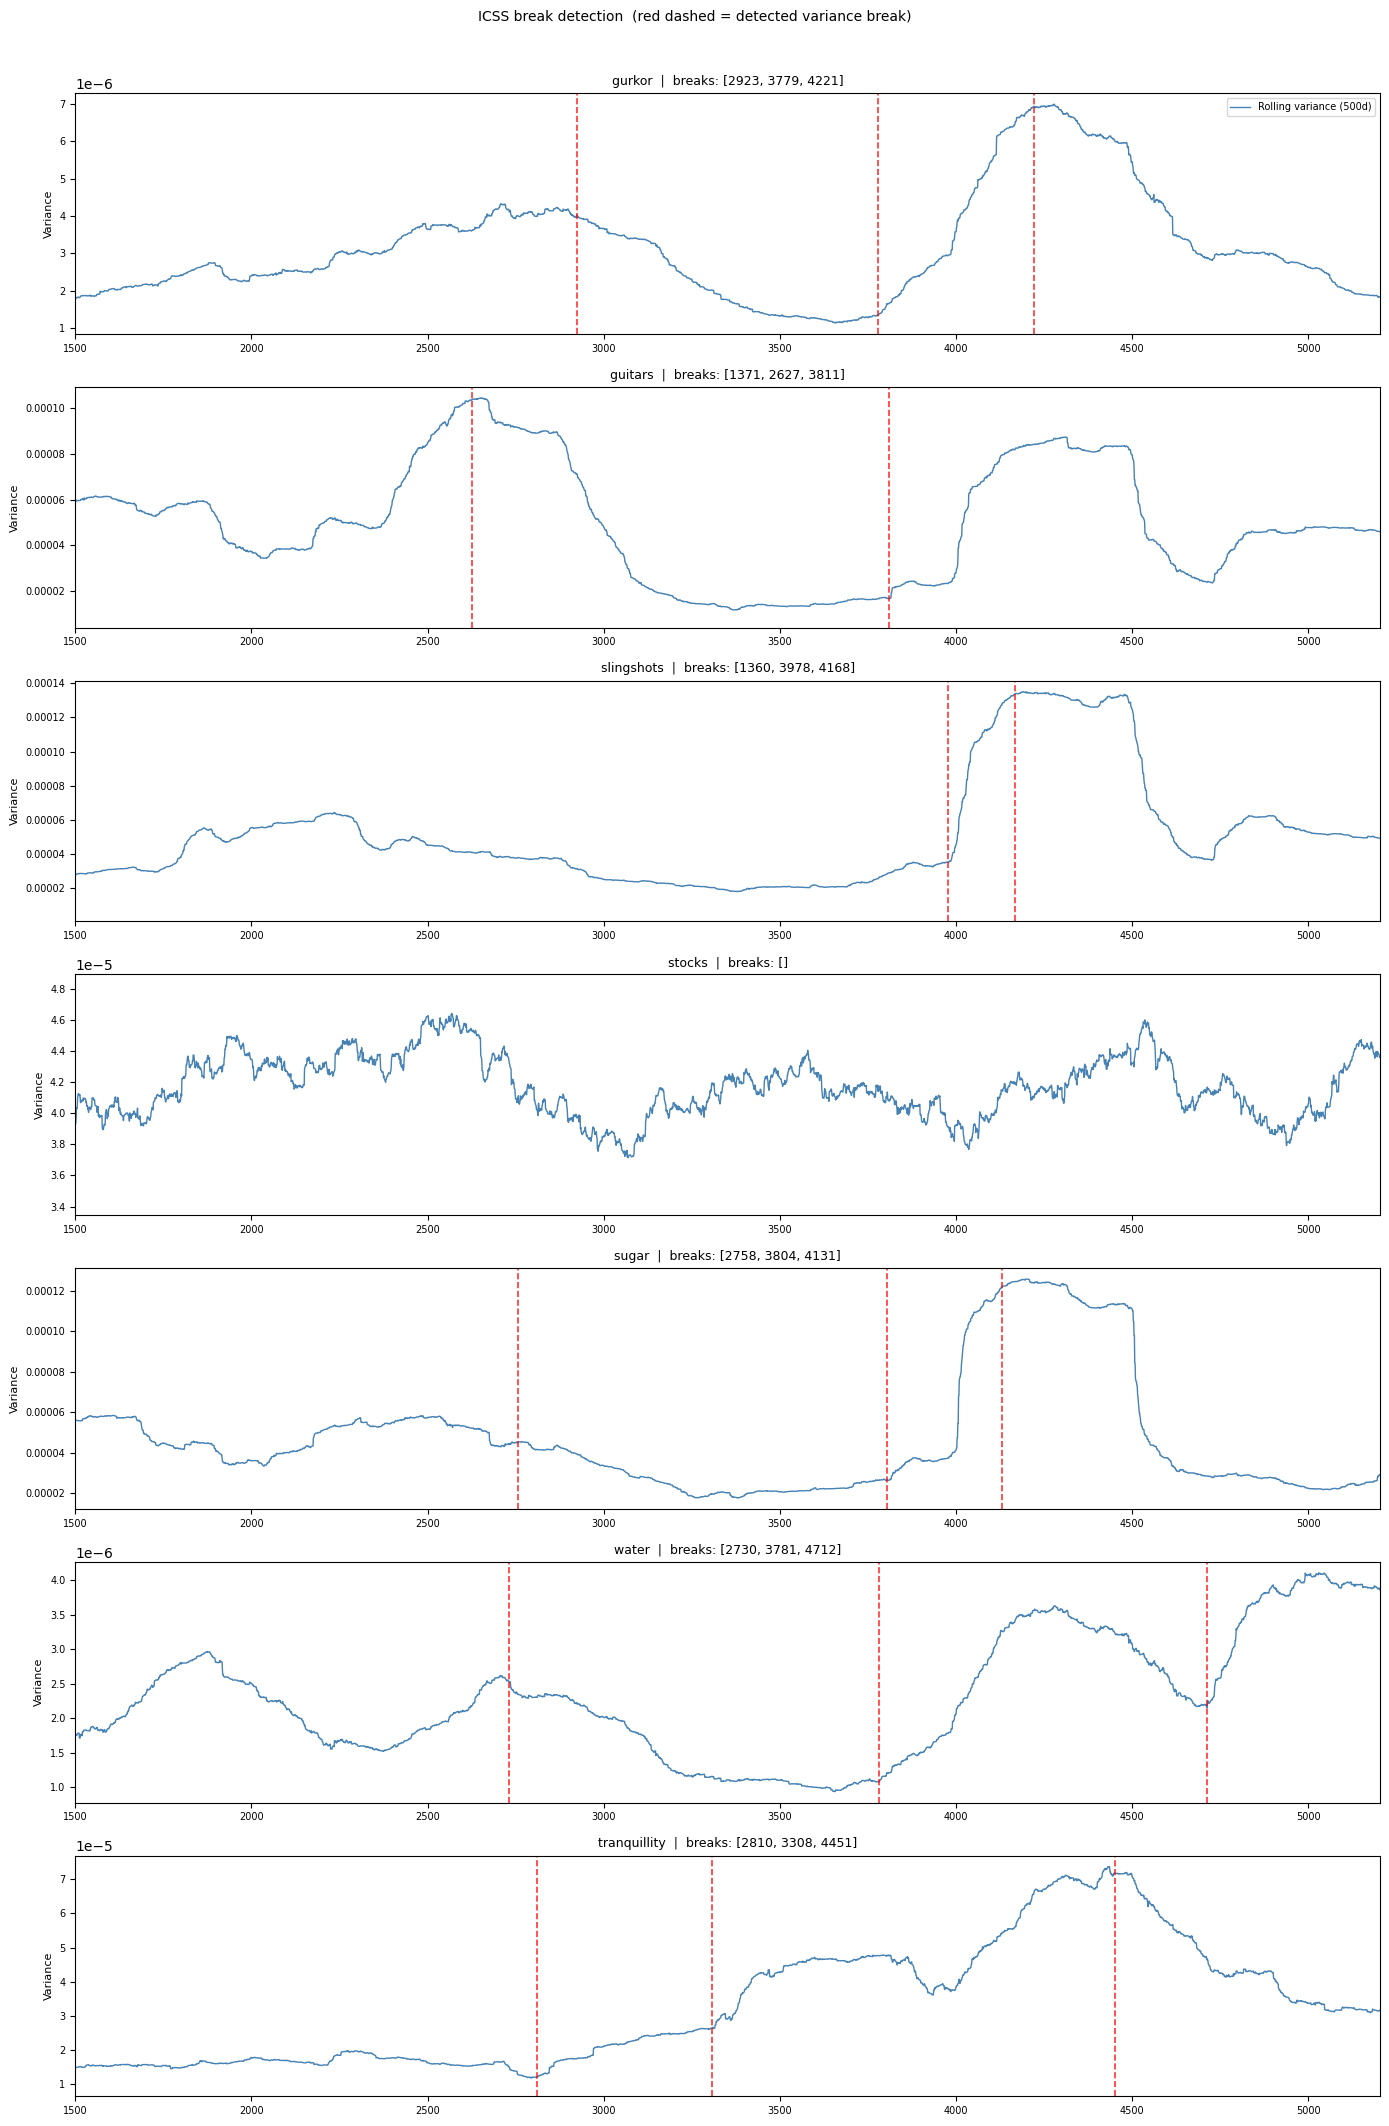


=== Detected break points ===
  gurkor                [np.int64(2923), np.int64(3779), np.int64(4221)]
  guitars               [np.int64(1371), np.int64(2627), np.int64(3811)]
  slingshots            [np.int64(1360), np.int64(3978), np.int64(4168)]
  stocks                []
  sugar                 [np.int64(2758), np.int64(3804), np.int64(4131)]
  water                 [np.int64(2730), np.int64(3781), np.int64(4712)]
  tranquillity          [np.int64(2810), np.int64(3308), np.int64(4451)]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings


def icss(x: np.ndarray, kappa: float = 1.358) -> list[int]:
    """
    Inclán & Tiao (1994) ICSS algorithm for variance break detection.

    Returns the list of break-point indices in `x` (operating on squared returns).
    `kappa` is the critical value at the 5% significance level.
    """
    x2 = x ** 2
    n = len(x2)
    cum = np.cumsum(x2)
    total = cum[-1]

    def _find_break(start, end):
        seg = x2[start:end]
        m = end - start
        if m < 10:
            return None
        cum_seg = np.cumsum(seg)
        denom = cum_seg[-1] if cum_seg[-1] > 0 else 1
        Dk = cum_seg / denom - np.arange(1, m + 1) / m
        Tk = np.abs(Dk) * np.sqrt(m)
        idx = np.argmax(Tk)
        if Tk[idx] > kappa:
            return start + idx
        return None

    breaks = []
    start, end = 0, n
    while True:
        bp = _find_break(1500, end)
        if bp is None:
            break
        breaks.append(bp)
        left = _find_break(start, bp)
        right = _find_break(bp, end)
        if left is None and right is None:
            break
        if left is not None:
            breaks.append(left)
            start = left
        if right is not None:
            breaks.append(right)
            end = right
        breaks = sorted(set(breaks))
        start = breaks[-1]
        if start >= end - 10:
            break

    return sorted(set(breaks))


# Run ICSS on each series and plot the rolling variance with detected breaks.
fig, axes = plt.subplots(len(val_cols), 1, figsize=(14, 3 * len(val_cols)))
axes = np.array(axes).flatten()

break_points = {}

for ax, col in zip(axes, val_cols):
    name = col.replace("_logreturn", "")
    r = df_clean[col].dropna().values
    bps = icss(r)
    break_points[col] = bps

    roll_var = pd.Series(r ** 2).rolling(500, min_periods=100).mean().values
    ax.set_xlim(1500, len(roll_var))

    ax.plot(roll_var, color="steelblue", lw=1.0, label="Rolling variance (500d)")
    for bp in bps:
        ax.axvline(bp, color="red", lw=1.2, ls="--", alpha=0.8)
    clean_bps = [int(b) for b in bps]
    ax.set_title(f"{name}  |  breaks: {clean_bps}", fontsize=9)
    ax.set_ylabel("Variance", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
fig.suptitle("ICSS break detection  (red dashed = detected variance break)", fontsize=10, y=1.01)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "icss_breaks.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Detected break points ===")
for col, bps in break_points.items():
    print(f"  {col.replace('_logreturn',''):<20}  {bps}")


In [6]:
# Compare three training-window strategies on a GARCH(1,1)-normal baseline.

ROLLING_N = 1000
results_window = {}

for col in val_cols:
    name = col.replace("_logreturn", "")
    spec = GARCHSpec(vol="Garch", p=1, q=1, dist="normal")
    r = df_clean[col].dropna()
    n = len(r)
    horizon = FORECAST_HORIZON

    train_full = r.iloc[:-horizon]
    bps = break_points[col]
    last_bp = bps[-1] if bps else 0
    train_postbreak = r.iloc[last_bp:-horizon] if last_bp > 0 else train_full
    train_rolling = r.iloc[max(0, n - horizon - ROLLING_N):-horizon]
    actual = r.iloc[-horizon:].values

    row = {"series": name, "n_full": len(train_full),
           "n_postbreak": len(train_postbreak), "n_rolling": len(train_rolling),
           "last_break": last_bp}

    for label, train in [("full", train_full),
                         ("post-break", train_postbreak),
                         ("rolling-1000", train_rolling)]:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = fit(train, spec)
                fc = res.forecast(horizon=horizon, reindex=False)
                var_fc = fc.variance.values[-1] / (100 ** 2)
            var_fc = np.maximum(var_fc, 1e-12)
            qlike = float(np.mean(np.log(var_fc) + actual ** 2 / var_fc))
        except Exception:
            qlike = np.nan
        row[f"QLIKE {label}"] = round(qlike, 5)

    ql = {k: row[f"QLIKE {k}"] for k in ["full", "post-break", "rolling-1000"]
          if not np.isnan(row.get(f"QLIKE {k}", np.nan))}
    row["best window"] = min(ql, key=ql.get) if ql else "full"
    results_window[col] = row

window_df = pd.DataFrame(results_window.values()).set_index("series")
print("=== Window comparison — holdout QLIKE ===")
print(window_df[["n_full", "n_postbreak", "n_rolling",
                 "QLIKE full", "QLIKE post-break", "QLIKE rolling-1000",
                 "last_break", "best window"]].to_string())
window_df


=== Window comparison — holdout QLIKE ===
              n_full  n_postbreak  n_rolling  QLIKE full  QLIKE post-break  QLIKE rolling-1000  last_break   best window
series                                                                                                                  
gurkor          5003          782       1000   -12.44278         -12.49233           -12.56915        4221  rolling-1000
guitars         5003         1192       1000    -9.80964          -9.65529            -9.77833        3811          full
slingshots      5003          835       1000    -9.87598          -9.67832            -9.65832        4168          full
stocks          5003         5003       1000    -8.96398          -8.96398            -8.96464           0  rolling-1000
sugar           5003          872       1000    -9.22725          -9.10904            -9.13365        4131          full
water           5003          291       1000   -12.14363         -11.80587           -12.00435        4712     

,n_full,n_postbreak,n_rolling,last_break,QLIKE full,QLIKE post-break,QLIKE rolling-1000,best window
series,,,,,,,,
gurkor,5003,782,1000,4221,-12.44278,-12.49233,-12.56915,rolling-1000
guitars,5003,1192,1000,3811,-9.80964,-9.65529,-9.77833,full
slingshots,5003,835,1000,4168,-9.87598,-9.67832,-9.65832,full
stocks,5003,5003,1000,0,-8.96398,-8.96398,-8.96464,rolling-1000
sugar,5003,872,1000,4131,-9.22725,-9.10904,-9.13365,full
water,5003,291,1000,4712,-12.14363,-11.80587,-12.00435,full
tranquillity,5003,552,1000,4451,-9.49026,-9.48065,-9.44362,full


### Interpretation

The best window per series is chosen by lowest holdout QLIKE.
This drives the `train_window` setting used in the GARCH fitting pipeline:
- **full** → use all training data
- **post-break** → start from the ICSS-detected break point
- **rolling-1000** → use the last 1000 observations only

The selected windows are applied in the KC' selection and validation cells below.

## GARCH order selection

The order `(p, q)` of the GARCH variance equation is selected via the KC'
criterion of Bardet, Karé & Kengne (2021, eq. 5.5). Unlike AIC, which Bardet et
al. prove to be asymptotically inconsistent for this model class (Theorem 4.4),
KC' achieves both consistency and good finite-sample efficiency by replacing
the fixed `log n` BIC penalty with a Hessian-based correction.


In [7]:
garch_specs, kc_stats = select_all_series(
    train_df, val_cols,
    max_ar=0,
    max_garch_p=2,
    max_garch_q=2,
)

print(f"  {'Series':<35}  KC\' selected")
print("  " + "-"*55)
for col, spec in garch_specs.items():
    print(f"  {col:<35}  GARCH({spec.p},{spec.q})")


  gurkor_logreturn                     AR(0)-GARCH(1,1)  [dist=TBD]


/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03008. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03008. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_sc

  guitars_logreturn                    AR(0)-GARCH(2,1)  [dist=TBD]
  slingshots_logreturn                 AR(0)-GARCH(1,1)  [dist=TBD]
  stocks_logreturn                     AR(0)-GARCH(1,1)  [dist=TBD]
  sugar_logreturn                      AR(0)-GARCH(2,1)  [dist=TBD]
  water_logreturn                      AR(0)-GARCH(1,2)  [dist=TBD]


/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02349. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02349. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_sc

  tranquillity_logreturn               AR(0)-GARCH(1,1)  [dist=TBD]
  Series                               KC' selected
  -------------------------------------------------------
  gurkor_logreturn                     GARCH(1,1)
  guitars_logreturn                    GARCH(2,1)
  slingshots_logreturn                 GARCH(1,1)
  stocks_logreturn                     GARCH(1,1)
  sugar_logreturn                      GARCH(2,1)
  water_logreturn                      GARCH(1,2)
  tranquillity_logreturn               GARCH(1,1)


In [8]:
from dataclasses import replace as _replace

# Window assignments validated empirically by the DM test below.
# Only gurkor and guitars benefit from a regime-aware window; all other series
# use the full sample.
WINDOW_CONFIG = {
    "gurkor_logreturn":  dict(train_window="rolling",    window_size=1000),
    "guitars_logreturn": dict(train_window="post_break", start_day=2607),
}

garch_specs = {
    col: _replace(spec, **WINDOW_CONFIG.get(col, dict(train_window="full")))
    for col, spec in garch_specs.items()
}

print(f"  {'Series':<35}  {'Window':<25}  GARCH order")
print("  " + "-" * 75)
for col, spec in garch_specs.items():
    name = col.replace("_logreturn", "")
    if spec.train_window == "rolling":
        win_str = f"rolling({spec.window_size})"
    elif spec.train_window == "post_break":
        win_str = f"post-break(day {spec.start_day})"
    else:
        win_str = "full"
    print(f"  {name:<35}  {win_str:<25}  GARCH({spec.p},{spec.q})")


  Series                               Window                     GARCH order
  ---------------------------------------------------------------------------
  gurkor                               rolling(1000)              GARCH(1,1)
  guitars                              post-break(day 2607)       GARCH(2,1)
  slingshots                           full                       GARCH(1,1)
  stocks                               full                       GARCH(1,1)
  sugar                                full                       GARCH(2,1)
  water                                full                       GARCH(1,2)
  tranquillity                         full                       GARCH(1,1)


### KC' candidate scores

Full grid of KC' values for every `(p, q)` candidate per series. The lowest
value in each block is the selected order.


In [9]:
kc_display = (
    kc_stats
    .assign(series=kc_stats["series"].str.replace("_logreturn","",regex=False))
    .sort_values(["series","candidate"]).reset_index(drop=True)
)
kc_display.style.format({"kc_prime":"{:.2f}"}).apply(
    lambda c: ["background-color:#d4edda" if v else "" for v in kc_display["selected"]],
    axis=0, subset=["kc_prime"])

print("=== KC' order selection ===")
print(kc_display.to_string(index=False))

=== KC' order selection ===
      series        candidate  ar  p  q   kc_prime  selected
     guitars AR(0)-GARCH(1,1)   0  1  1  8236.1586     False
     guitars AR(0)-GARCH(1,2)   0  1  2  8246.6578     False
     guitars AR(0)-GARCH(2,1)   0  2  1  8229.6738      True
     guitars AR(0)-GARCH(2,2)   0  2  2  8239.1240     False
      gurkor AR(0)-GARCH(1,1)   0  1  1 -3829.5616      True
      gurkor AR(0)-GARCH(1,2)   0  1  2 -3819.4130     False
      gurkor AR(0)-GARCH(2,1)   0  2  1 -3827.2036     False
      gurkor AR(0)-GARCH(2,2)   0  2  2 -3828.5882     False
  slingshots AR(0)-GARCH(1,1)   0  1  1  7739.5358      True
  slingshots AR(0)-GARCH(1,2)   0  1  2  7750.5732     False
  slingshots AR(0)-GARCH(2,1)   0  2  1  7746.2246     False
  slingshots AR(0)-GARCH(2,2)   0  2  2  7751.7351     False
      stocks AR(0)-GARCH(1,1)   0  1  1  9886.5765      True
      stocks AR(0)-GARCH(1,2)   0  1  2  9895.0963     False
      stocks AR(0)-GARCH(2,1)   0  2  1  9933.0436     Fa

In [10]:
# KC' selection summary per series.
# Shows the selected order, its KC' value, and the runner-up.-up, margin, and verdict

rows = []
for series, grp in kc_display.groupby('series', sort=True):
    grp_s = grp.sort_values('kc_prime')
    selected  = grp_s[grp_s['selected']]
    others    = grp_s[~grp_s['selected']]

    sel_kc    = selected['kc_prime'].values[0]
    sel_order = f"GARCH({selected['p'].values[0]},{selected['q'].values[0]})"

    runner    = others.iloc[0]  # second-best (closest KC')
    run_kc    = runner['kc_prime']
    run_order = f"GARCH({int(runner['p'])},{int(runner['q'])})"
    margin    = run_kc - sel_kc   # positive = selected is better by this much

    verdict = "clear" if margin > 5 else "borderline"

    rows.append(dict(series=series, selected=sel_order, kc=sel_kc,
                     runner_up=run_order, runner_kc=run_kc,
                     margin=margin, verdict=verdict))

import pandas as pd
interp = pd.DataFrame(rows).set_index("series")

print(f"{'Series':<14}  {'Selected':<12}  {'KC prime':>10}  {'Runner-up':<12}  {'Runner KC':>10}  {'Margin':>8}  Verdict")
print("-" * 85)
for name, r in interp.iterrows():
    print(f"{name:<14}  {r.selected:<12}  {r.kc:>10.2f}  {r.runner_up:<12}  {r.runner_kc:>10.2f}  {r.margin:>8.2f}  {r.verdict}")

print()
print("Notes:")
print(" - Margin = KC' (runner-up) - KC' (selected). Positive means selected is better.")
print(" - 'borderline' = margin < 5 (selected vs runner-up are close).")
print(" - 'clear' = margin > 5 (selected is unambiguously best).")


Series          Selected        KC prime  Runner-up      Runner KC    Margin  Verdict
-------------------------------------------------------------------------------------
guitars         GARCH(2,1)       8229.67  GARCH(1,1)       8236.16      6.48  clear
gurkor          GARCH(1,1)      -3829.56  GARCH(2,2)      -3828.59      0.97  borderline
slingshots      GARCH(1,1)       7739.54  GARCH(2,1)       7746.22      6.69  clear
stocks          GARCH(1,1)       9886.58  GARCH(1,2)       9895.10      8.52  clear
sugar           GARCH(2,1)       8802.25  GARCH(1,1)       8802.39      0.14  borderline
tranquillity    GARCH(1,1)       7319.12  GARCH(1,2)       7329.47     10.35  clear
water           GARCH(1,2)      -5126.31  GARCH(2,1)      -5119.63      6.68  clear

Notes:
 - Margin = KC' (runner-up) - KC' (selected). Positive means selected is better.
 - 'borderline' = margin < 5 (selected vs runner-up are close).
 - 'clear' = margin > 5 (selected is unambiguously best).


## Distribution selection

With the GARCH `(p, q)` order fixed, the innovation distribution is selected
on the training sample by AICC and a sequential likelihood-ratio test (LRT):

- **Normal → t**: LR ~ χ²(1), with H₀ being ν → ∞ (Gaussian tails).
- **t → skew-t**: LR ~ χ²(1), with H₀ being λ = 0 (no asymmetry).

The procedure is applied independently to the GARCH and EGARCH families,
because their standardised residuals differ.


In [11]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from dataclasses import replace as _replace

def _aicc(res):
    n, k = res.nobs, len(res.params)
    return -2*res.loglikelihood + 2*k + 2*k*(k+1)/max(n-k-1, 1)

def _dist_test(specs, df, label, alpha=0.05):
    rows = []
    for col, spec in specs.items():
        name = col.replace("_logreturn","")
        row = {"series": name}
        fitted = {}
        for dist in ["normal","t","skewt"]:
            s = GARCHSpec(vol=spec.vol, p=spec.p, q=spec.q,
                          ar_order=spec.ar_order, ma_order=0, dist=dist)
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fitted[dist] = fit(df[col], s)
                row[f"AICC({dist})"] = round(_aicc(fitted[dist]), 1)
            except Exception:
                row[f"AICC({dist})"] = np.nan

            # Sequential LRT gate (normal -> t -> skewt).
        # Step 1: Normal vs t  (H0: nu -> inf)
        if "normal" in fitted and "t" in fitted:
            lr = 2*(fitted["t"].loglikelihood - fitted["normal"].loglikelihood)
            p_t_vs_n = float(stats.chi2.sf(lr, 1))
            row["p(t vs N)"] = round(p_t_vs_n, 4)
        else:
            p_t_vs_n = 1.0
            row["p(t vs N)"] = np.nan

        # Step 2: t vs skewed-t  (H0: lambda = 0)
        if "t" in fitted and "skewt" in fitted:
            lr = 2*(fitted["skewt"].loglikelihood - fitted["t"].loglikelihood)
            p_lam = float(stats.chi2.sf(lr, 1))
            row["p(λ=0)"] = round(p_lam, 4)
        else:
            p_lam = 1.0
            row["p(λ=0)"] = np.nan

        # Selection: sequential LRT — stop as soon as we fail to reject
        if p_t_vs_n < alpha:
            if p_lam < alpha:
                best = "skewt"
            else:
                best = "t"
        else:
            best = "normal"

        row["best dist"] = best
        rows.append(row)

    df_out = pd.DataFrame(rows).set_index("series")
    print(f"=== Distribution test — {label} ===")
    print(df_out.to_string())
    return df_out

dist_garch  = _dist_test(garch_specs, train_df, "GARCH")
dist_garch


=== Distribution test — GARCH ===
              AICC(normal)  AICC(t)  AICC(skewt)  p(t vs N)  p(λ=0) best dist
series                                                                       
gurkor             -3903.5  -4095.1      -4106.1        0.0  0.0003     skewt
guitars             8148.1   7993.5       7968.9        0.0  0.0000     skewt
slingshots          7670.7   7577.2       7521.5        0.0  0.0000     skewt
stocks              9860.5   9863.5       9851.6        1.0  0.0002    normal
sugar               8721.9   8516.0       8512.4        0.0  0.0183     skewt
water              -5158.9  -5350.2      -5352.8        0.0  0.0319     skewt
tranquillity        7248.7   7053.0       7053.7        0.0  0.2487         t


,AICC(normal),AICC(t),AICC(skewt),p(t vs N),p(λ=0),best dist
series,,,,,,
gurkor,-3903.5,-4095.1,-4106.1,0.0,0.0003,skewt
guitars,8148.1,7993.5,7968.9,0.0,0.0000,skewt
slingshots,7670.7,7577.2,7521.5,0.0,0.0000,skewt
stocks,9860.5,9863.5,9851.6,1.0,0.0002,normal
sugar,8721.9,8516.0,8512.4,0.0,0.0183,skewt
water,-5158.9,-5350.2,-5352.8,0.0,0.0319,skewt
tranquillity,7248.7,7053.0,7053.7,0.0,0.2487,t


In [12]:
# EGARCH variants reuse the KC'-selected (p, q) orders from GARCH; only the
# variance equation changes.
egarch_specs = {
    col: _replace(spec, vol="EGARCH")
    for col, spec in garch_specs.items()
}

dist_egarch = _dist_test(egarch_specs, train_df, "EGARCH")
dist_egarch


=== Distribution test — EGARCH ===
              AICC(normal)  AICC(t)  AICC(skewt)  p(t vs N)  p(λ=0) best dist
series                                                                       
gurkor             -3913.1  -4110.3      -4111.2     0.0000  0.0901         t
guitars             8156.7   7992.7       7969.3     0.0000  0.0000     skewt
slingshots          7714.4   7608.5       7557.6     0.0000  0.0000     skewt
stocks              9859.5   9860.1       9850.1     0.2484  0.0005    normal
sugar               8746.6   8526.4       8523.3     0.0000  0.0234     skewt
water              -5154.4  -5344.7      -5346.4     0.0000  0.0544         t
tranquillity        7278.4   7074.4       7075.4     0.0000  0.2979         t


,AICC(normal),AICC(t),AICC(skewt),p(t vs N),p(λ=0),best dist
series,,,,,,
gurkor,-3913.1,-4110.3,-4111.2,0.0000,0.0901,t
guitars,8156.7,7992.7,7969.3,0.0000,0.0000,skewt
slingshots,7714.4,7608.5,7557.6,0.0000,0.0000,skewt
stocks,9859.5,9860.1,9850.1,0.2484,0.0005,normal
sugar,8746.6,8526.4,8523.3,0.0000,0.0234,skewt
water,-5154.4,-5344.7,-5346.4,0.0000,0.0544,t
tranquillity,7278.4,7074.4,7075.4,0.0000,0.2979,t


In [13]:
# Apply the AICC/LRT-selected distribution to each model set.
garch_specs = {
    col: _replace(spec, dist=dist_garch.loc[col.replace("_logreturn",""), "best dist"])
    for col, spec in garch_specs.items()
}
egarch_specs = {
    col: _replace(spec, dist=dist_egarch.loc[col.replace("_logreturn",""), "best dist"])
    for col, spec in egarch_specs.items()
}

print("Final specifications:")
print(f"  {'Series':<35}  {'GARCH':<35}  EGARCH")
print("  " + "-"*90)
for col in val_cols:
    print(f"  {col:<35}  {str(garch_specs[col]):<35}  {egarch_specs[col]}")


Final specifications:
  Series                               GARCH                                EGARCH
  ------------------------------------------------------------------------------------------
  gurkor_logreturn                     const-Garch(1,1)-skewt[roll1000]     const-EGARCH(1,1)-t[roll1000]
  guitars_logreturn                    const-Garch(2,1)-skewt[post2607]     const-EGARCH(2,1)-skewt[post2607]
  slingshots_logreturn                 const-Garch(1,1)-skewt               const-EGARCH(1,1)-skewt
  stocks_logreturn                     const-Garch(1,1)-normal              const-EGARCH(1,1)-normal
  sugar_logreturn                      const-Garch(2,1)-skewt               const-EGARCH(2,1)-skewt
  water_logreturn                      const-Garch(1,2)-skewt               const-EGARCH(1,2)-t
  tranquillity_logreturn               const-Garch(1,1)-t                   const-EGARCH(1,1)-t


## Baseline specification

GARCH(1,1) with Gaussian innovations is the standard benchmark in the
volatility-forecasting literature (Hansen & Lunde 2005). The Table 9 DM test
compares this baseline trained on the regime-aware window against the same
specification trained on the full sample.


In [ ]:
baseline_specs = {col: GARCHSpec(vol="Garch", p=1, q=1, dist="normal") for col in val_cols}

# Window-aware variants of the baseline

baseline_window_specs = {
    col: _replace(spec, **WINDOW_CONFIG.get(col, dict(train_window="full")))
    for col, spec in baseline_specs.items()
}

print("Baseline: GARCH(1,1)-normal for all series")


Baseline: GARCH(1,1)-normal for all series


## Holdout evaluation

Each specification is fitted on `df_clean[:-200]` and used to forecast the last
200 observations. The primary loss is QLIKE:

QLIKE = (1/T) Σ [log σ̂²_t + r²_t / σ̂²_t]

QLIKE is robust to the noisy realised-variance proxy `r²_t` (Patton 2011) and
is the basis for the model comparison.


In [15]:
holdout_bas        = evaluate_holdout_all_series(df_clean, baseline_specs,         horizon=FORECAST_HORIZON, n_paths=N_PATHS)
holdout_bas_window = evaluate_holdout_all_series(df_clean, baseline_window_specs,  horizon=FORECAST_HORIZON, n_paths=N_PATHS)
holdout_garch      = evaluate_holdout_all_series(df_clean, garch_specs,            horizon=FORECAST_HORIZON, n_paths=N_PATHS)
holdout_egar       = evaluate_holdout_all_series(df_clean, egarch_specs,           horizon=FORECAST_HORIZON, n_paths=N_PATHS)

hs_bas   = holdout_summary(holdout_bas)
hs_garch = holdout_summary(holdout_garch)
hs_egar  = holdout_summary(holdout_egar)

print("=== Holdout QLIKE ===")
qlike_df = pd.DataFrame({
    "GARCH(1,1)-normal": hs_bas["qlike"].round(5),
    "GARCH(KC\')":        hs_garch["qlike"].round(5),
    "EGARCH(KC\')":       hs_egar["qlike"].round(5),
})
print(qlike_df.to_string())


  Holdout gurkor_logreturn (const-Garch(1,1)-normal) ... 

/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03008. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


RMSE-mean=0.001000  QLIKE=-12.4428  RMSE-vol=0.000002
  Holdout guitars_logreturn (const-Garch(1,1)-normal) ... RMSE-mean=0.003662  QLIKE=-9.8096  RMSE-vol=0.000035
  Holdout slingshots_logreturn (const-Garch(1,1)-normal) ... RMSE-mean=0.004021  QLIKE=-9.8760  RMSE-vol=0.000037
  Holdout stocks_logreturn (const-Garch(1,1)-normal) ... RMSE-mean=0.006847  QLIKE=-8.9640  RMSE-vol=0.000063
  Holdout sugar_logreturn (const-Garch(1,1)-normal) ... RMSE-mean=0.006162  QLIKE=-9.2273  RMSE-vol=0.000083
  Holdout water_logreturn (const-Garch(1,1)-normal) ... 

/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02349. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


RMSE-mean=0.001334  QLIKE=-12.1436  RMSE-vol=0.000003
  Holdout tranquillity_logreturn (const-Garch(1,1)-normal) ... RMSE-mean=0.005255  QLIKE=-9.4903  RMSE-vol=0.000052
  Holdout gurkor_logreturn (const-Garch(1,1)-normal[roll1000]) ... 

...

RMSE-mean=0.001334  QLIKE=-12.0325  RMSE-vol=0.000004
  Holdout tranquillity_logreturn (const-Garch(1,1)-t) ... RMSE-mean=0.005255  QLIKE=-9.4901  RMSE-vol=0.000052
  Holdout gurkor_logreturn (const-EGARCH(1,1)-t[roll1000]) ... 

/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0396. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


RMSE-mean=0.001005  QLIKE=-12.6037  RMSE-vol=0.000002
  Holdout guitars_logreturn (const-EGARCH(2,1)-skewt[post2607]) ... RMSE-mean=0.003663  QLIKE=-9.8305  RMSE-vol=0.000034
  Holdout slingshots_logreturn (const-EGARCH(1,1)-skewt) ... RMSE-mean=0.004020  QLIKE=-9.7988  RMSE-vol=0.000040
  Holdout stocks_logreturn (const-EGARCH(1,1)-normal) ... RMSE-mean=0.006847  QLIKE=-8.9626  RMSE-vol=0.000063
  Holdout sugar_logreturn (const-EGARCH(2,1)-skewt) ... RMSE-mean=0.006166  QLIKE=-9.2248  RMSE-vol=0.000083
  Holdout water_logreturn (const-EGARCH(1,2)-t) ... 

/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02349. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


RMSE-mean=0.001335  QLIKE=-12.0595  RMSE-vol=0.000004
  Holdout tranquillity_logreturn (const-EGARCH(1,1)-t) ... RMSE-mean=0.005255  QLIKE=-9.4915  RMSE-vol=0.000052
=== Holdout QLIKE ===
                        GARCH(1,1)-normal  GARCH(KC')  EGARCH(KC')
series                                                            
gurkor_logreturn                -12.44278   -12.53623    -12.60371
guitars_logreturn                -9.80964    -9.75624     -9.83050
slingshots_logreturn             -9.87598    -9.84467     -9.79884
stocks_logreturn                 -8.96398    -8.96398     -8.96264
sugar_logreturn                  -9.22725    -9.24423     -9.22483
water_logreturn                 -12.14363   -12.03248    -12.05953
tranquillity_logreturn           -9.49026    -9.49009     -9.49155


## Diebold-Mariano test for window selection

The Harvey-Leybourne-Newbold (1997) modified DM test on per-step QLIKE losses,
applied only to the baseline GARCH(1,1)-normal trained on the regime-aware
window versus the full sample.

H₀ is equal predictive accuracy. A negative DM statistic indicates that the row
model wins. significance at the 5% level.


In [16]:
def _dm(h1, h2, label1, label2):
    """
    Harvey-Leybourne-Newbold (1997) modified Diebold-Mariano test on per-step
    QLIKE losses. Returns a per-series result DataFrame.
    """
    rows = []
    for col in val_cols:
        actual = h1[col]["actual"]
        v1 = np.maximum(h1[col]["forecast_var"], 1e-12)
        v2 = np.maximum(h2[col]["forecast_var"], 1e-12)
        l1 = np.log(v1) + actual ** 2 / v1
        l2 = np.log(v2) + actual ** 2 / v2
        d = l1 - l2
        T = len(d)
        # 1-step forecasts use the contemporaneous variance only; longer
        # Newey-West lags collapse the long-run variance estimate.
        gamma0 = np.var(d, ddof=0)
        lrv = max(gamma0, 1e-12)
        dm_raw = np.mean(d) / np.sqrt(lrv / T)
        hln_factor = np.sqrt((T + 1 - 2 + 1 / T) / T)
        dm = dm_raw * hln_factor
        p = float(2 * (1 - stats.t.cdf(abs(dm), df=T - 1)))
        rows.append({
            "series": col.replace("_logreturn", ""),
            f"QLIKE {label1}": round(np.mean(l1), 5),
            f"QLIKE {label2}": round(np.mean(l2), 5),
            "diff":            round(np.mean(d), 5),
            "DM stat":         round(dm, 3),
            "p-value":         round(p, 4),
            "result": f"{label1} wins*" if (np.mean(d) < 0 and p < 0.05) else
                      f"{label1} wins"  if np.mean(d) < 0 else
                      f"{label2} wins*" if p < 0.05 else f"{label2} wins",
        })
    df = pd.DataFrame(rows).set_index("series")
    print(f"=== DM test: {label1} vs {label2} ===")
    print(df.to_string())
    return df


# Baseline on regime-aware window vs baseline on full sample.
dm_window_vs_full = _dm(holdout_bas_window, holdout_bas,
                        "baseline(window)", "baseline(full)")


=== DM test: baseline(window) vs baseline(full) ===
              QLIKE baseline(window)  QLIKE baseline(full)     diff  DM stat  p-value                  result
series                                                                                                       
gurkor                     -12.56915             -12.44278 -0.12637  -12.109      0.0  baseline(window) wins*
guitars                     -9.88726              -9.80964 -0.07762  -13.283      0.0  baseline(window) wins*
slingshots                  -9.87598              -9.87598  0.00000    0.000      1.0     baseline(full) wins
stocks                      -8.96398              -8.96398  0.00000    0.000      1.0     baseline(full) wins
sugar                       -9.22725              -9.22725  0.00000    0.000      1.0     baseline(full) wins
water                      -12.14363             -12.14363  0.00000    0.000      1.0     baseline(full) wins
tranquillity                -9.49026              -9.49026  0.00000 

In [17]:
# Summary of which series benefit from a regime-aware window.
rows = []
for col in val_cols:
    name = col.replace("_logreturn", "")
    spec_w = baseline_window_specs[col]
    if spec_w.train_window == "rolling":
        win_label = f"rolling({spec_w.window_size})"
    elif spec_w.train_window == "post_break":
        win_label = f"post-break(day {spec_w.start_day})"
    else:
        win_label = "full"

    row_w = dm_window_vs_full.loc[name]
    use_win = "window wins*" in row_w["result"]
    rows.append({
        "series":        name,
        "window tested": win_label,
        "DM result":     row_w["result"],
        "use window?":   "yes" if use_win else "no",
    })
window_selection = pd.DataFrame(rows).set_index("series")
print("=== Window selection summary ===")
print(window_selection.to_string())


=== Window selection summary ===
                     window tested               DM result use window?
series                                                                
gurkor               rolling(1000)  baseline(window) wins*          no
guitars       post-break(day 2607)  baseline(window) wins*          no
slingshots                    full     baseline(full) wins          no
stocks                        full     baseline(full) wins          no
sugar                         full     baseline(full) wins          no
water                         full     baseline(full) wins          no
tranquillity                  full     baseline(full) wins          no


## Holdout QLIKE comparison

Mean QLIKE per series for the three candidate specifications.

In [18]:
rows = []
for col in val_cols:
    name = col.replace("_logreturn","")
    rows.append({
        "series":               name,
        "GARCH spec":           str(garch_specs[col]),
        "EGARCH spec":          str(egarch_specs[col]),
        "holdout QLIKE base":   round(hs_bas.loc[col,"qlike"],5),
        "holdout QLIKE GARCH":  round(hs_garch.loc[col,"qlike"],5),
        "holdout QLIKE EGARCH": round(hs_egar.loc[col,"qlike"],5),
    })
comp = pd.DataFrame(rows).set_index("series")
print("=== Full comparison ===")
print(comp.to_string())
comp


=== Full comparison ===
                                    GARCH spec                        EGARCH spec  holdout QLIKE base  holdout QLIKE GARCH  holdout QLIKE EGARCH
series                                                                                                                                          
gurkor        const-Garch(1,1)-skewt[roll1000]      const-EGARCH(1,1)-t[roll1000]           -12.44278            -12.53623             -12.60371
guitars       const-Garch(2,1)-skewt[post2607]  const-EGARCH(2,1)-skewt[post2607]            -9.80964             -9.75624              -9.83050
slingshots              const-Garch(1,1)-skewt            const-EGARCH(1,1)-skewt            -9.87598             -9.84467              -9.79884
stocks                 const-Garch(1,1)-normal           const-EGARCH(1,1)-normal            -8.96398             -8.96398              -8.96264
sugar                   const-Garch(2,1)-skewt            const-EGARCH(2,1)-skewt            -9.22725     

,GARCH spec,EGARCH spec,holdout QLIKE base,holdout QLIKE GARCH,holdout QLIKE EGARCH
series,,,,,
gurkor,"const-Garch(1,1)-skewt[roll1000]","const-EGARCH(1,1)-t[roll1000]",-12.44278,-12.53623,-12.60371
guitars,"const-Garch(2,1)-skewt[post2607]","const-EGARCH(2,1)-skewt[post2607]",-9.80964,-9.75624,-9.83050
slingshots,"const-Garch(1,1)-skewt","const-EGARCH(1,1)-skewt",-9.87598,-9.84467,-9.79884
stocks,"const-Garch(1,1)-normal","const-EGARCH(1,1)-normal",-8.96398,-8.96398,-8.96264
sugar,"const-Garch(2,1)-skewt","const-EGARCH(2,1)-skewt",-9.22725,-9.24423,-9.22483
water,"const-Garch(1,2)-skewt","const-EGARCH(1,2)-t",-12.14363,-12.03248,-12.05953
tranquillity,"const-Garch(1,1)-t","const-EGARCH(1,1)-t",-9.49026,-9.49009,-9.49155


In [19]:
# Pick the lowest-QLIKE specification per series across the three candidates.
final_specs: dict[str, GARCHSpec] = {}
holdout_final: dict[str, dict] = {}
for col in val_cols:
    q_b = hs_bas.loc[col, "qlike"]
    q_g = hs_garch.loc[col, "qlike"]
    q_e = hs_egar.loc[col, "qlike"]
    winners = {
        "baseline": (q_b, baseline_specs[col], holdout_bas[col]),
        "garch":    (q_g, garch_specs[col],    holdout_garch[col]),
        "egarch":   (q_e, egarch_specs[col],   holdout_egar[col]),
    }
    best_label = min(winners, key=lambda k: winners[k][0])
    _, spec, hres = winners[best_label]
    final_specs[col] = spec
    holdout_final[col] = hres
    print(f"  {col:35s}  {best_label:9s}  QLIKE={winners[best_label][0]:.4f}  {spec}")


  gurkor_logreturn                     egarch     QLIKE=-12.6037  const-EGARCH(1,1)-t[roll1000]
  guitars_logreturn                    egarch     QLIKE=-9.8305  const-EGARCH(2,1)-skewt[post2607]
  slingshots_logreturn                 baseline   QLIKE=-9.8760  const-Garch(1,1)-normal
  stocks_logreturn                     baseline   QLIKE=-8.9640  const-Garch(1,1)-normal
  sugar_logreturn                      garch      QLIKE=-9.2442  const-Garch(2,1)-skewt
  water_logreturn                      baseline   QLIKE=-12.1436  const-Garch(1,1)-normal
  tranquillity_logreturn               egarch     QLIKE=-9.4915  const-EGARCH(1,1)-t


## Holdout backtest

Left panel: forecast volatility vs realised |r_t|. Right panel: simulated
price fan against the observed price. The model is fitted on training data
only, so these are genuine out-of-sample forecasts. The "winning" model per
series is the one with the lowest holdout QLIKE.


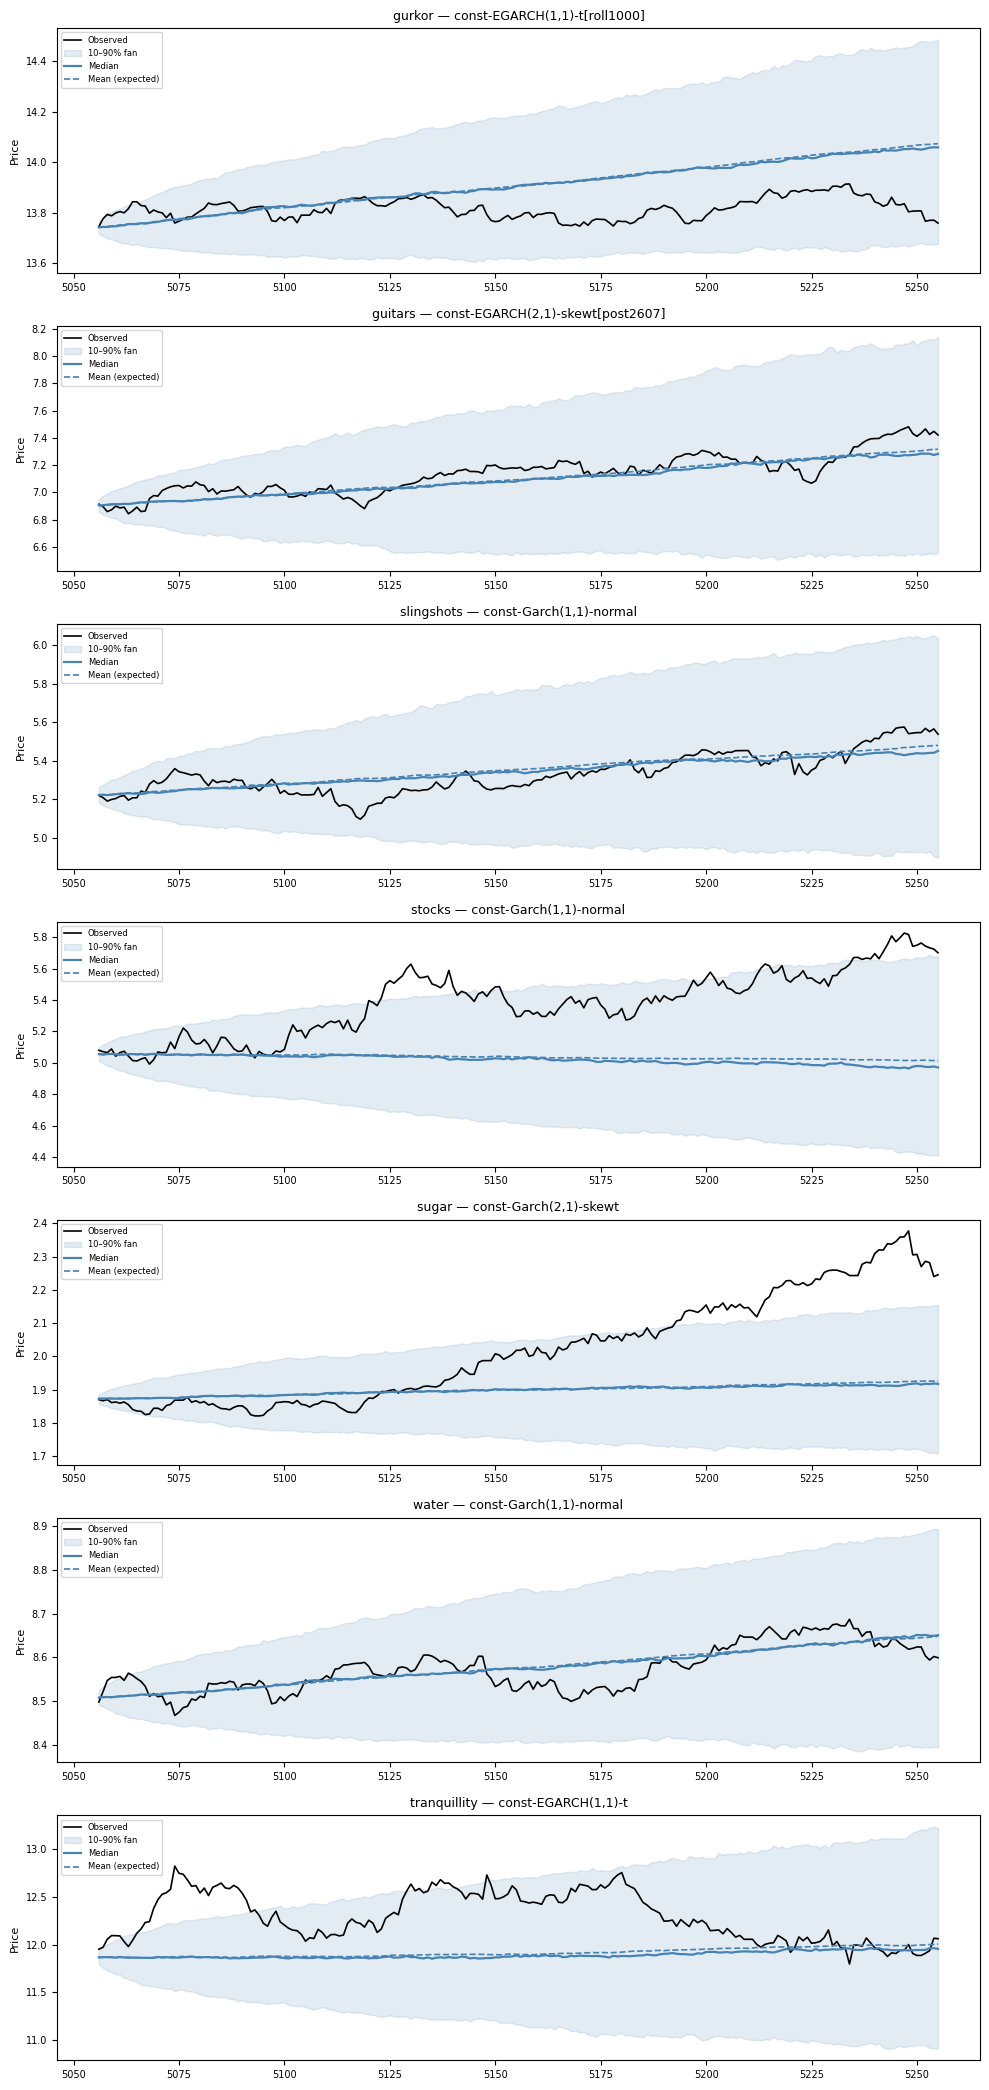

In [20]:
import matplotlib.pyplot as plt

n = len(val_cols)

# Price panel: simulated price fan with median and mean against the observed price.
fig_price, axes_price = plt.subplots(n, 1, figsize=(10, 3.0 * n))
axes_price = np.array(axes_price).flatten()

for row_i, col in enumerate(val_cols):
    name = col.replace("_logreturn", "")
    actual = holdout_final[col]["actual"]
    idx = holdout_final[col]["actual_index"]

    last_train_price = float(prices_df[name].dropna().iloc[-(len(actual) + 1)])
    actual_prices = last_train_price * np.exp(np.cumsum(actual))

    sim_paths = holdout_final[col]["simulated_return_paths"]
    pp = last_train_price * np.exp(np.cumsum(sim_paths, axis=1))
    p10, p50, p90 = np.percentile(pp, [10, 50, 90], axis=0)
    mean_path = np.mean(pp, axis=0)

    ax = axes_price[row_i]
    ax.plot(idx, actual_prices, color="black", lw=1.2, label="Observed")
    ax.fill_between(idx, p10, p90, color="steelblue", alpha=0.15, label="10–90% fan")
    ax.plot(idx, p50, color="steelblue", lw=1.6, ls="-", label="Median")
    ax.plot(idx, mean_path, color="steelblue", lw=1.2, ls="--", label="Mean (expected)")
    ax.set_title(f"{name} — {final_specs[col]}", fontsize=9)
    ax.set_ylabel("Price", fontsize=8)
    ax.legend(fontsize=6, loc="upper left")
    ax.tick_params(labelsize=7)

fig_price.tight_layout()
fig_price.savefig(OUTPUT_DIR / "holdout_price_backtest.png", dpi=150, bbox_inches="tight")
plt.show()


## MCS

In [ ]:
import mcs as _mcs

# ARMA orders from Table 7 of the report (AIC selection on log-returns).
ARMA_ORDERS = {
    "gurkor_logreturn":       (2, 0),
    "guitars_logreturn":      (0, 3),
    "slingshots_logreturn":   (2, 4),
    "stocks_logreturn":       (0, 0),
    "sugar_logreturn":        (4, 0),
    "water_logreturn":        (0, 3),
    "tranquillity_logreturn": (0, 0),
}

# GARCH-side specs
# already attached to garch_specs / egarch_specs from the distribution test.
GARCH_SPECS_BY_COL = {
    col: {"p": spec.p, "q": spec.q, "dist": spec.dist}
    for col, spec in garch_specs.items()
}


In [22]:
# Compute the per-step QLIKE and squared-error losses on the 200-day holdout
# for each of the six candidates, then assemble a T×K loss DataFrame per series.

def _candidate_losses(col):
    series = df_clean[col].dropna().values
    train, test = series[:-FORECAST_HORIZON], series[-FORECAST_HORIZON:]
    arma_order = ARMA_ORDERS[col]
    gs = GARCH_SPECS_BY_COL[col]
    p, q, dist = gs["p"], gs["q"], gs["dist"]

    candidates = {
        "RW":               _mcs.forecast_rw(train, FORECAST_HORIZON),
    }
    # ARMA(0,0) collapses to the RW benchmark — including both would feed two
    # bit-identical loss columns into the MCS and trigger a divide-by-zero in
    # the bootstrap variance. Add ARMA only when it differs from RW.
    if arma_order != (0, 0):
        candidates["ARMA"] = _mcs.forecast_arma(train, FORECAST_HORIZON, arma_order)
    candidates.update({
        "GARCH(1,1)-norm":  _mcs.forecast_garch(train, FORECAST_HORIZON, p=1, q=1, dist="normal"),
        "GARCH(KC')":       _mcs.forecast_garch(train, FORECAST_HORIZON, p=p, q=q, dist=dist),
        "EGARCH(KC')":      _mcs.forecast_garch(train, FORECAST_HORIZON, p=p, q=q, dist=dist, vol="EGARCH"),
    })
    if arma_order != (0, 0):
        candidates["ARMA-GARCH"] = _mcs.forecast_arma_garch(
            train, FORECAST_HORIZON,
            arma_order=arma_order, p=p, q=q, dist=dist,
            n_paths=1000,
        )

    var_losses, mean_losses = {}, {}
    for name, (mu_hat, var_hat) in candidates.items():
        L = _mcs.per_step_losses(test, mu_hat, var_hat)
        var_losses[name] = L["qlike"]
        mean_losses[name] = L["se_mean"]
    return pd.DataFrame(var_losses), pd.DataFrame(mean_losses)


candidate_losses = {}
for col in val_cols:
    print(f"  Building candidate losses for {col} ...", flush=True)
    candidate_losses[col] = _candidate_losses(col)


  Building candidate losses for gurkor_logreturn ...


/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Building candidate losses for guitars_logreturn ...


/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Building candidate losses for slingshots_logreturn ...


/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Building candidate losses for stocks_logreturn ...
  Building candidate losses for sugar_logreturn ...
  Building candidate losses for water_logreturn ...
  Building candidate losses for tranquillity_logreturn ...


In [23]:
# Run the MCS on the QLIKE losses (variance comparison) and the SE losses
# (mean comparison) per series.
mcs_var = [
    _mcs.run_mcs(candidate_losses[col][0], asset=col, loss_name="QLIKE")
    for col in val_cols
]
mcs_mean = [
    _mcs.run_mcs(candidate_losses[col][1], asset=col, loss_name="SE-mean")
    for col in val_cols
]

def _mcs_pvalue_table(results):
    rows = {r.asset.replace("_logreturn",""): r.pvalues.reindex(_mcs.FAMILIES) for r in results}
    return pd.DataFrame(rows).T[_mcs.FAMILIES].round(3)

print("=== MCS p-values — QLIKE (variance) ===")
print(_mcs_pvalue_table(mcs_var).to_string())
print()
print("=== MCS p-values — SE-mean (mean) ===")
print(_mcs_pvalue_table(mcs_mean).to_string())


=== MCS p-values — QLIKE (variance) ===
                 RW   ARMA  GARCH(1,1)-norm  GARCH(KC')  EGARCH(KC')  ARMA-GARCH
gurkor        0.000  0.000            0.000       0.000        1.000       0.000
guitars       0.000  0.000            1.000       0.000        0.233       0.011
slingshots    0.000  0.000            1.000       0.007        0.000       0.007
stocks        1.000    NaN            1.000       1.000        1.000         NaN
sugar         0.041  0.041            0.220       1.000        0.040       0.009
water         0.077  1.000            0.003       0.000        0.000       0.003
tranquillity  1.000    NaN            0.902       0.902        0.620         NaN

=== MCS p-values — SE-mean (mean) ===
                 RW   ARMA  GARCH(1,1)-norm  GARCH(KC')  EGARCH(KC')  ARMA-GARCH
gurkor        1.000  1.000            1.000       1.000        1.000       1.000
guitars       0.363  0.202            1.000       0.687        0.600       0.039
slingshots    0.737  0.737    

/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/bootstrap/multiple_comparison.py:220: RuntimeWarning: invalid value encountered in divide
  std_loss_diffs = loss_diffs / np.sqrt(variances)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/bootstrap/multiple_comparison.py:221: RuntimeWarning: invalid value encountered in divide
  std_bs_mean_losses = bootstrapped_mean_losses / np.sqrt(variances)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/bootstrap/multiple_comparison.py:220: RuntimeWarning: invalid value encountered in divide
  std_loss_diffs = loss_diffs / np.sqrt(variances)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11/site-packages/arch/bootstrap/multiple_comparison.py:221: RuntimeWarning: invalid value encountered in divide
  std_bs_mean_losses = bootstrapped_mean_losses / np.sqrt(variances)
/Users/ericsangberg/anaconda3/envs/timeseries_env/lib/python3.11

## Final model selection

Selection is driven by the QLIKE MCS because the data has essentially no mean
predictability (flat ACF/PACF in Task 1, and the SE-mean MCS retains every
candidate for most series). For each series we take the most parsimonious model
that survives the variance MCS at α = 0.10.


In [24]:
selection = _mcs.select_from_mcs(mcs_var)

def _selection_table(selection, results):
    by_asset = {r.asset: r for r in results}
    rows = []
    for col, fam in selection.items():
        name = col.replace("_logreturn","")
        r = by_asset[col]
        rows.append({
            "asset":       name,
            "family":      fam,
            "MCS p-value": round(float(r.pvalues.get(fam, float("nan"))), 3),
            "survivors":   ", ".join(r.included),
        })
    return pd.DataFrame(rows)

print("=== Final selection (most parsimonious MCS survivor on QLIKE) ===")
print(_selection_table(selection, mcs_var).to_string(index=False))


=== Final selection (most parsimonious MCS survivor on QLIKE) ===
       asset          family  MCS p-value                                    survivors
      gurkor     EGARCH(KC')         1.00                                  EGARCH(KC')
     guitars GARCH(1,1)-norm         1.00                 EGARCH(KC'), GARCH(1,1)-norm
  slingshots GARCH(1,1)-norm         1.00                              GARCH(1,1)-norm
      stocks              RW         1.00 RW, GARCH(1,1)-norm, GARCH(KC'), EGARCH(KC')
       sugar GARCH(1,1)-norm         0.22                  GARCH(1,1)-norm, GARCH(KC')
       water            ARMA         1.00                                         ARMA
tranquillity              RW         1.00 EGARCH(KC'), GARCH(1,1)-norm, GARCH(KC'), RW


## Final forecast

Each selected model is refit on the full observed sample and Monte Carlo
simulated 200 days forward. The price fan
plots the 10-90 % envelope together with the path-wise median (central
forecast) and the path-wise mean (expected price under the model).


In [25]:
import matplotlib.pyplot as plt

N_PATHS_FWD = 1000
HISTORY_START_DAY = 4500   # earliest observed day shown next to the forecast

forward_returns = {}
for col, family in selection.items():
    series = df_clean[col].dropna().values
    arma_order = ARMA_ORDERS[col]
    gs = GARCH_SPECS_BY_COL[col]
    print(f"  Simulating {col} with {family} ...", flush=True)
    forward_returns[col] = _mcs.simulate_forward(
        family, series,
        arma_order=arma_order, garch_spec=gs,
        horizon=FORECAST_HORIZON, n_paths=N_PATHS_FWD,
    )


  Simulating gurkor_logreturn with EGARCH(KC') ...
  Simulating guitars_logreturn with GARCH(1,1)-norm ...
  Simulating slingshots_logreturn with GARCH(1,1)-norm ...
  Simulating stocks_logreturn with RW ...
  Simulating sugar_logreturn with GARCH(1,1)-norm ...
  Simulating water_logreturn with ARMA ...
  Simulating tranquillity_logreturn with RW ...


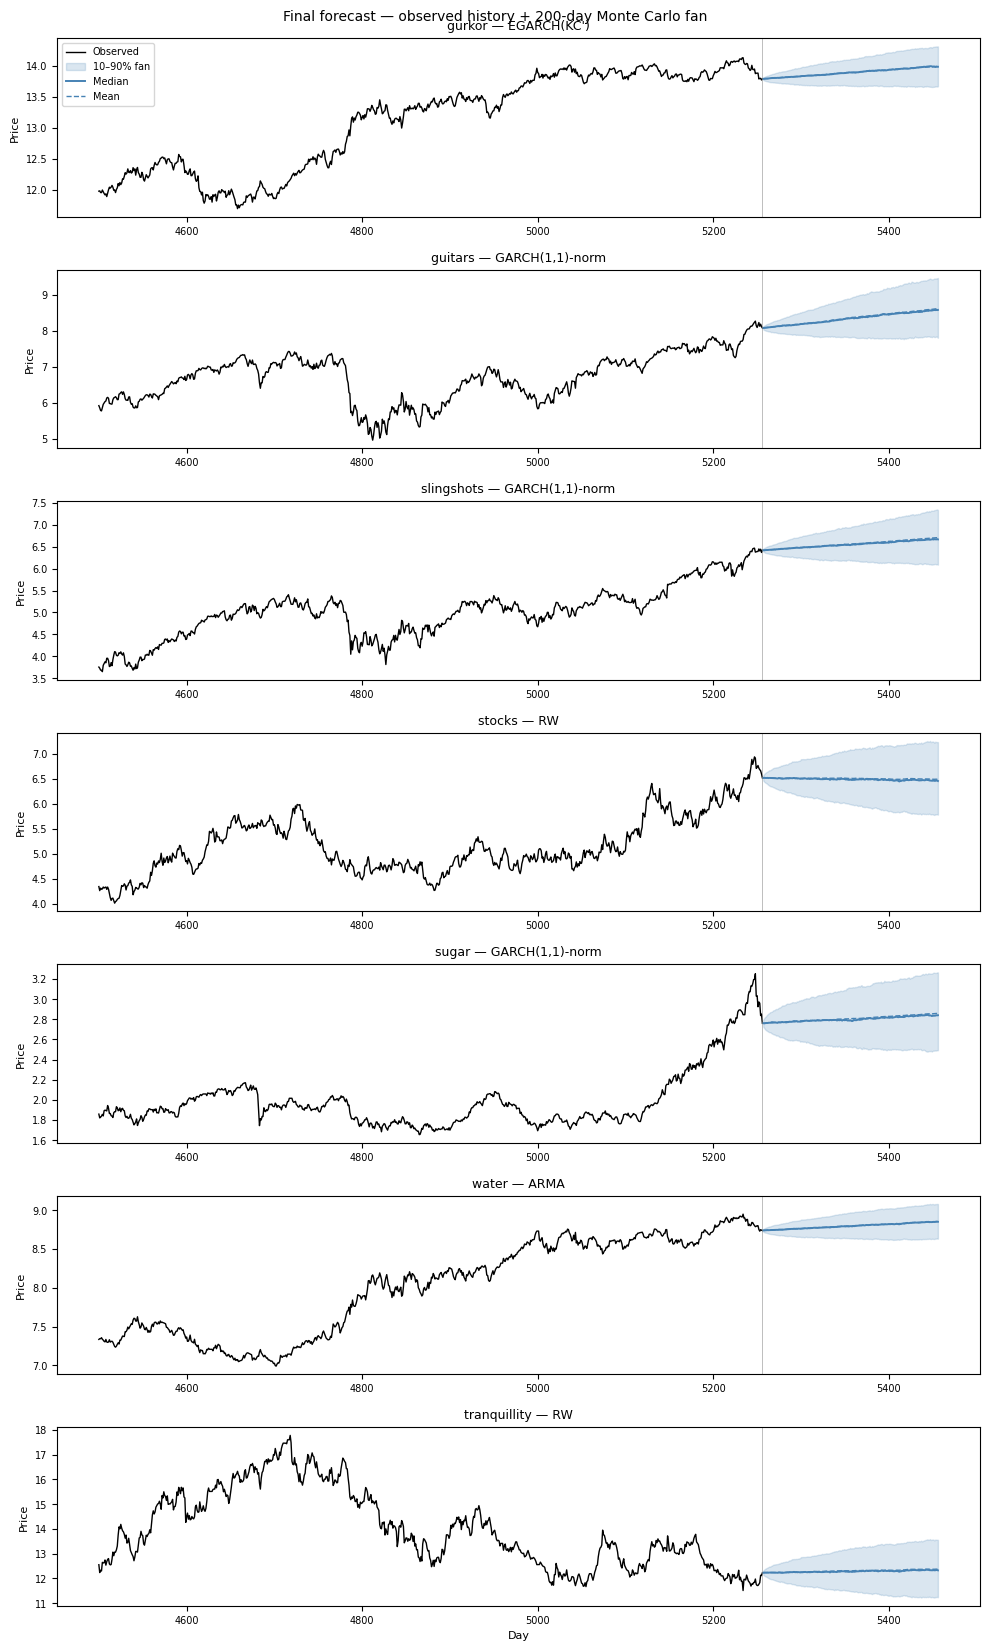

In [26]:
# Plot the final forecast for each series: observed history from
# HISTORY_START_DAY through to the last observed day, then the forecast fan.
n = len(val_cols)
fig, axes = plt.subplots(n, 1, figsize=(10, 2.4 * n), sharex=False)
axes = np.array(axes).flatten()

for ax, col in zip(axes, val_cols):
    name = col.replace("_logreturn", "")
    obs = prices_df[name].dropna()
    obs = obs.loc[obs.index >= HISTORY_START_DAY]
    last_day = int(obs.index.max())
    p0 = float(obs.iloc[-1])

    ret_paths = forward_returns[col]
    pp = _mcs.price_paths(ret_paths, p0)
    q10, q50, q90 = np.percentile(pp, [10, 50, 90], axis=0)
    mean_path = pp.mean(axis=0)
    forecast_days = np.arange(last_day + 1, last_day + 1 + FORECAST_HORIZON)

    ax.plot(obs.index, obs.values, color="black", lw=1.0, label="Observed")
    ax.fill_between(forecast_days, q10, q90, color="steelblue", alpha=0.20, label="10–90% fan")
    ax.plot(forecast_days, q50, color="steelblue", lw=1.4, label="Median")
    ax.plot(forecast_days, mean_path, color="steelblue", lw=1.0, ls="--", label="Mean")
    ax.axvline(last_day, color="grey", lw=0.6, alpha=0.6)
    ax.set_title(f"{name} — {selection[col]}", fontsize=9)
    ax.set_ylabel("Price", fontsize=8)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel("Day", fontsize=8)
axes[0].legend(loc="upper left", fontsize=7)
fig.suptitle("Final forecast — observed history + 200-day Monte Carlo fan", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_forecast_fan.png", dpi=150, bbox_inches="tight")
plt.show()


## Holdout backtest under the MCS selection

Each MCS-selected model is refit on `series[:-200]` and used to generate 1000
Monte Carlo paths over the holdout. The observed price during the same 200-day
window is overlaid for direct comparison.


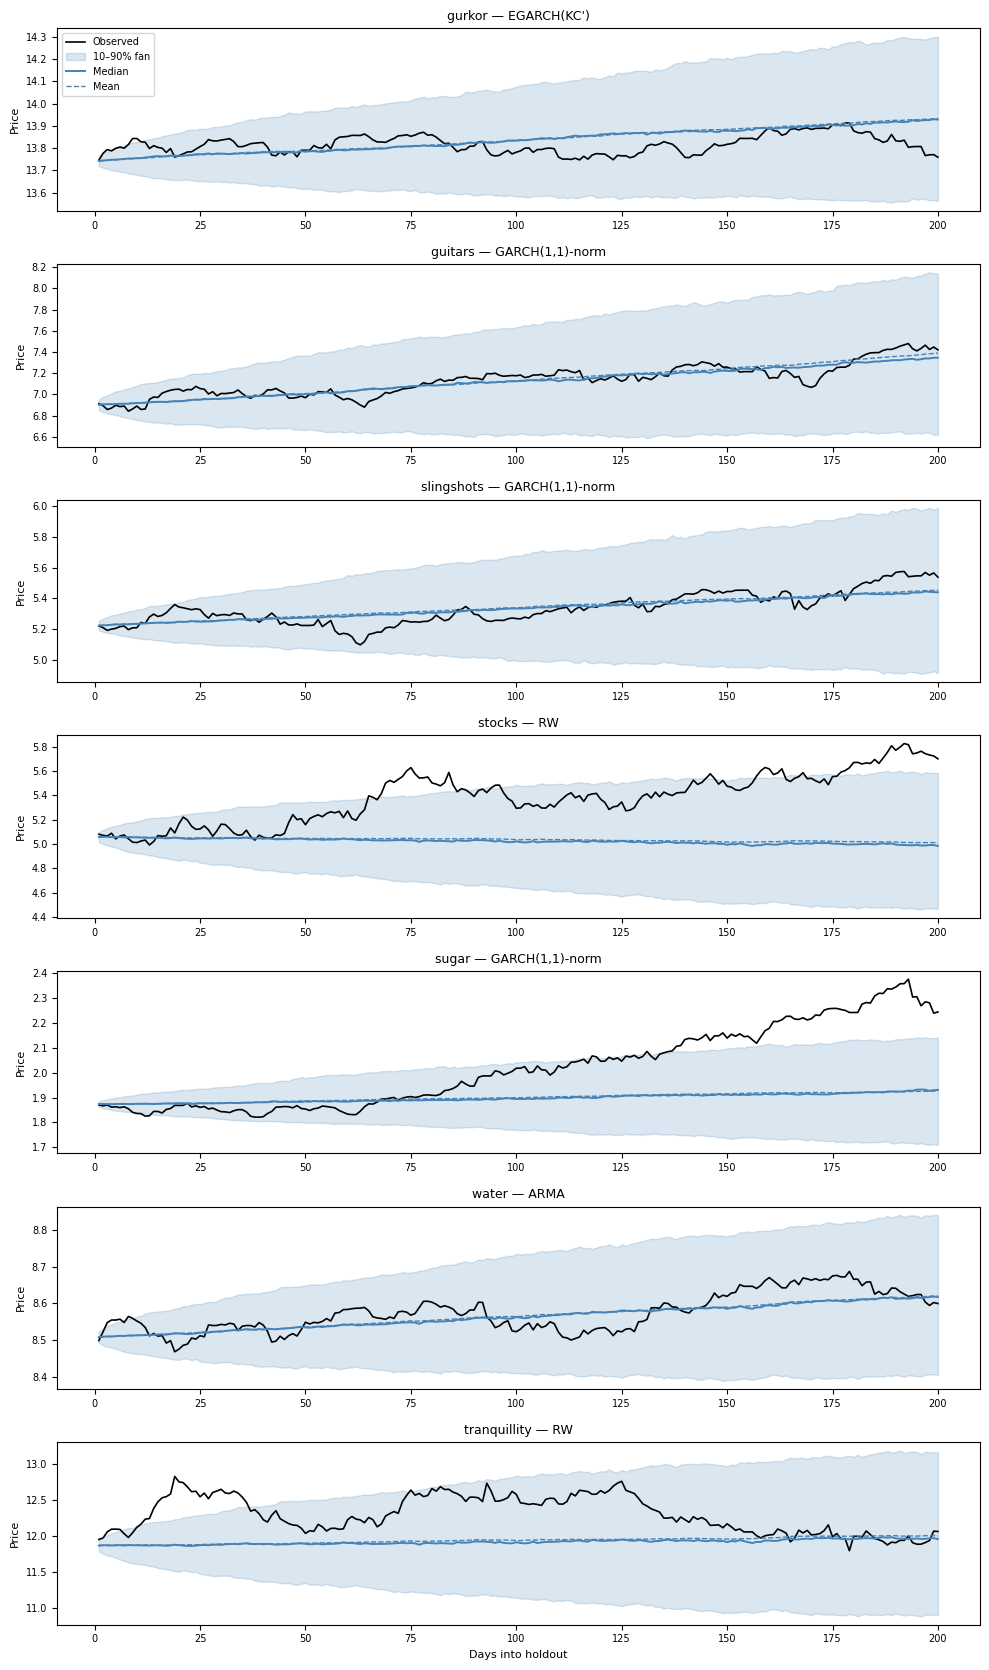

In [27]:
# Simulate holdout paths under the MCS-selected model per series.
holdout_mcs_paths = {}
for col, family in selection.items():
    series = df_clean[col].dropna().values
    train_pit = series[:-FORECAST_HORIZON]
    arma_order = ARMA_ORDERS[col]
    gs = GARCH_SPECS_BY_COL[col]
    holdout_mcs_paths[col] = _mcs.simulate_forward(
        family, train_pit,
        arma_order=arma_order, garch_spec=gs,
        horizon=FORECAST_HORIZON, n_paths=N_PATHS_FWD,
    )

n = len(val_cols)
fig, axes = plt.subplots(n, 1, figsize=(10, 2.4 * n), sharex=False)
axes = np.array(axes).flatten()

for ax, col in zip(axes, val_cols):
    name = col.replace("_logreturn", "")
    actual = df_clean[col].dropna().values[-FORECAST_HORIZON:]
    last_train_price = float(prices_df[name].dropna().iloc[-(len(actual) + 1)])
    actual_prices = last_train_price * np.exp(np.cumsum(actual))

    pp = _mcs.price_paths(holdout_mcs_paths[col], last_train_price)
    p10, p50, p90 = np.percentile(pp, [10, 50, 90], axis=0)
    mean_path = pp.mean(axis=0)
    horizon_axis = np.arange(1, FORECAST_HORIZON + 1)

    ax.plot(horizon_axis, actual_prices, color="black", lw=1.2, label="Observed")
    ax.fill_between(horizon_axis, p10, p90, color="steelblue", alpha=0.20, label="10–90% fan")
    ax.plot(horizon_axis, p50, color="steelblue", lw=1.4, label="Median")
    ax.plot(horizon_axis, mean_path, color="steelblue", lw=1.0, ls="--", label="Mean")
    ax.set_title(f"{name} — {selection[col]}", fontsize=9)
    ax.set_ylabel("Price", fontsize=8)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel("Days into holdout", fontsize=8)
axes[0].legend(loc="upper left", fontsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "holdout_backtest_mcs.png", dpi=150, bbox_inches="tight")
plt.show()


## PIT calibration

Under correct model specification `{u_h}` is uniform on `[0, 1]`. A mountain
shape indicates an over-dispersed forecast distribution (fan too wide), a
U-shape indicates under-dispersion, and slope indicates a biased mean. The
Kolmogorov-Smirnov p-value tests for uniformity (approximate because the
single-origin PIT values are correlated across horizons).


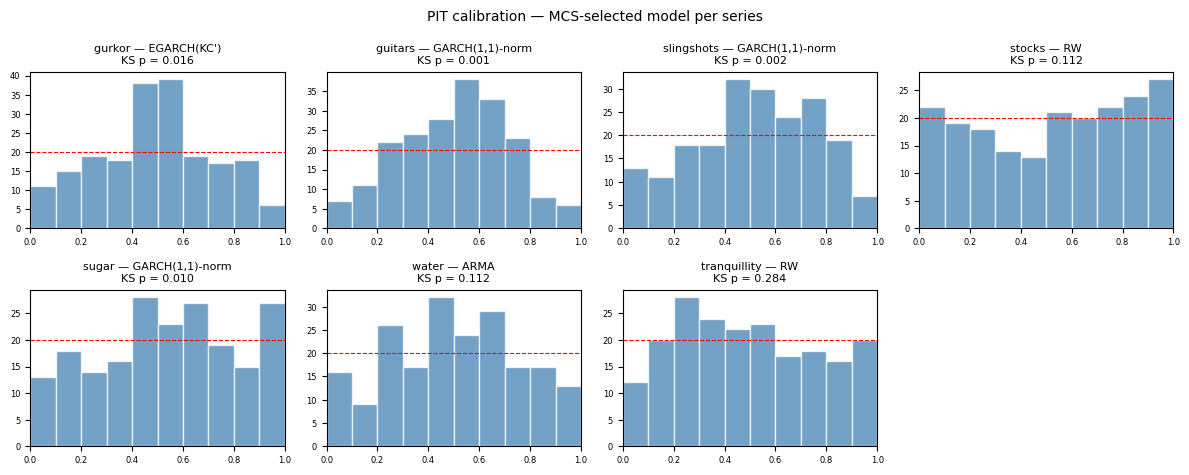

In [28]:
# Reuse holdout_mcs_paths from the holdout backtest cell above.
ncol = 4
nrow = (len(val_cols) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.4 * nrow))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, val_cols):
    name = col.replace("_logreturn", "")
    realized = df_clean[col].dropna().values[-FORECAST_HORIZON:]
    u, _, ks_p = _mcs.pit_check(realized, holdout_mcs_paths[col])
    ax.hist(u, bins=10, range=(0, 1), color="steelblue", alpha=0.75, edgecolor="white")
    ax.axhline(len(u) / 10, color="red", ls="--", lw=0.8)
    ax.set_title(f"{name} — {selection[col]}\nKS p = {ks_p:.3f}", fontsize=8)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=6)

for ax in axes[len(val_cols):]:
    ax.set_visible(False)

fig.suptitle("PIT calibration — MCS-selected model per series", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pit_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
